# Elo K-Factor Tuning (Per Gender)

**Question this notebook answers:** does tuning the Elo K-factor (how much each game moves a
team's rating) separately for men's and women's improve on the current best model? Every notebook
so far has used the same default K=20 for both genders, never tested against alternatives.

**Why K gets tuned on a separate window, not the real test folds:** picking whichever K happens
to score best on the 2021-2025 folds — the same folds used to judge the final result — would be
quietly cheating, since the "test" would no longer be honest. Instead, K is selected using
2016-2020 as a tuning window (walk-forward, same discipline as everywhere else in this project),
completely separate from the 2021-2025 folds used for the real evaluation. Whatever K comes out
of that tuning window gets locked in before touching the real test folds at all.

**A second thing fixed in this notebook:** while setting this up, a bug turned up in notebook 13's
conference-strength feature. Conference abbreviations (like `sec`, `acc`) are shared between the
men's and women's conference files — every single women's (season, conference) pair also appears
in the men's file. Grouping by `(Season, ConfAbbrev)` without also separating by gender meant
men's and women's teams in the same conference were silently averaged together. That's fixed here
by computing conference strength separately for each gender, and this notebook reports three
numbers side by side so the impact of the bug fix and the K-tuning can be told apart: notebook
13's original (buggy conference strength, K=20), a corrected version (gender-separated conference
strength, K=20 still), and the corrected version with tuned K.

## 1. Load data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_conf_teams = pd.read_csv(DATA_DIR / "MTeamConferences.csv")
w_conf_teams = pd.read_csv(DATA_DIR / "WTeamConferences.csv")

print(f"men's tourney games: {len(m_tourney):,}, women's tourney games: {len(w_tourney):,}")


men's tourney games: 2,585, women's tourney games: 1,717


## 2. Whole-season team features and seeds (unchanged from notebooks 03/07/11/13)

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        GamesPlayed=("Win", "size"), WinPct=("Win", "mean"),
        AvgPF=("PF", "mean"), AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)

def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum"]], w_seeds[["Season", "TeamID", "SeedNum"]]], ignore_index=True)
seed_idx = seeds.set_index(["Season", "TeamID"])["SeedNum"]
print(f"team-season rows: {len(team_stats):,}, seed rows: {len(seeds):,}")


team-season rows: 23,604, seed rows: 4,506


## 3. Elo and conference-strength functions

`compute_elo` is unchanged from notebook 11 (K is now a variable being tuned, not fixed at 20).
`compute_conf_strength` is new — it's the same idea as notebook 13, but called once per gender
on that gender's own conference-membership rows only, so a men's and women's team can never end
up averaged into the same group even if they share a conference abbreviation.

In [3]:
def compute_elo(games, k, home_adv=100, mean_reversion=0.75):
    elo = {}
    elo_by_season_end = {}
    for season in sorted(games["Season"].unique()):
        for team in elo:
            elo[team] = elo[team] * mean_reversion + 1500 * (1 - mean_reversion)
        season_games = games[games["Season"] == season].sort_values("DayNum")
        # itertuples instead of iterrows - same logic, much faster for repeated K-value trials
        for game in season_games.itertuples(index=False):
            w, l = game.WTeamID, game.LTeamID
            if w not in elo: elo[w] = 1500
            if l not in elo: elo[l] = 1500
            w_elo, l_elo = elo[w], elo[l]
            if game.WLoc == "H": w_elo += home_adv
            elif game.WLoc == "A": l_elo += home_adv
            w_exp = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            mov = game.WScore - game.LScore
            mov_mult = np.log(max(mov, 1) + 1) * (2.2 / ((w_elo - l_elo) * 0.001 + 2.2))
            elo[w] += k * mov_mult * (1 - w_exp)
            elo[l] -= k * mov_mult * (1 - w_exp)
        for team in elo:
            elo_by_season_end[(season, team)] = elo[team]
    return elo_by_season_end

def to_series(d):
    s = pd.Series(d)
    s.index = pd.MultiIndex.from_tuples(s.index, names=["Season", "TeamID"])
    return s

def compute_conf_strength(conf_teams, elo_series):
    ct = conf_teams.copy()
    ct["Elo"] = ct.apply(lambda r: elo_series.get((r["Season"], r["TeamID"]), np.nan), axis=1)
    ct = ct.dropna(subset=["Elo"])
    conf_avg = ct.groupby(["Season", "ConfAbbrev"])["Elo"].mean().rename("ConfStrength")
    merged = ct.merge(conf_avg, on=["Season", "ConfAbbrev"], how="left")
    return merged.set_index(["Season", "TeamID"])["ConfStrength"]

print("Elo and conference-strength functions ready")


Elo and conference-strength functions ready


## 4. K-factor tuning (2016-2020, separate from the real test folds)

For each gender independently, try a grid of K values, computing Elo and running the same
walk-forward evaluation used throughout this project — but on 2016-2020, not 2021-2025 — using
just the 4-feature model (Seed, WinPct, AvgMargin, Elo). Conference strength is left out of the
tuning step on purpose: it would need recomputing for every candidate K too, which would mix
"how good is this K for Elo" with "how good is this K for conference strength," making it harder
to tell what's actually being tuned. The K that scores best gets locked in before conference
strength or the real test folds are touched at all.

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def fit_logreg(X, y, l2=1.0, n_iter=50, tol=1e-8):
    n, p = X.shape
    Xb = np.hstack([np.ones((n, 1)), X])
    w = np.zeros(p + 1)
    reg = np.eye(p + 1) * l2
    reg[0, 0] = 0.0
    for _ in range(n_iter):
        pr = sigmoid(Xb @ w)
        grad = Xb.T @ (pr - y) + reg @ w
        W = np.clip(pr * (1 - pr), 1e-6, None)
        H = Xb.T @ (Xb * W[:, None]) + reg
        step = np.linalg.solve(H, grad)
        w_new = w - step
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    return w

def predict_proba(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

def build_single_gender_matchups(tourney, elo_series):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
    df["Seed1"] = df.apply(lambda r: seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
    df["Seed2"] = df.apply(lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
    df["SeedDiff"] = df["Seed2"] - df["Seed1"]
    df["Elo1"] = df.apply(lambda r: elo_series.get((r["Season"], r["Team1"]), np.nan), axis=1)
    df["Elo2"] = df.apply(lambda r: elo_series.get((r["Season"], r["Team2"]), np.nan), axis=1)
    df["EloDiff"] = df["Elo1"] - df["Elo2"]
    for team_col, suffix in [("Team1", "1"), ("Team2", "2")]:
        joined = df.merge(team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
        df[f"WinPct{suffix}"] = joined["WinPct"].values
        df[f"AvgMargin{suffix}"] = joined["AvgScoreMargin"].values
    df["WinPctDiff"] = df["WinPct1"] - df["WinPct2"]
    df["AvgMarginDiff"] = df["AvgMargin1"] - df["AvgMargin2"]
    features = ["SeedDiff", "WinPctDiff", "AvgMarginDiff", "EloDiff"]
    return df.dropna(subset=features).reset_index(drop=True), features

def walk_forward_brier(matchups, features, fold_seasons):
    briers, ns = [], []
    for fold_season in fold_seasons:
        train = matchups[matchups["Season"] < fold_season]
        test = matchups[matchups["Season"] == fold_season]
        if len(test) == 0 or len(train) == 0:
            continue
        w = fit_logreg(train[features].values, train["Label"].values)
        b = brier_score(predict_proba(test[features].values, w), test["Label"].values)
        briers.append(b)
        ns.append(len(test))
    return np.average(briers, weights=ns) if briers else np.nan

TUNING_FOLDS = [2016, 2017, 2018, 2019, 2020]
K_GRID = [10, 15, 20, 25, 30, 40, 50, 75, 100]

tuning_results = []
for gender_label, reg, tourney in [("Men", m_reg, m_tourney), ("Women", w_reg, w_tourney)]:
    for k in K_GRID:
        elo_series = to_series(compute_elo(reg, k=k))
        matchups_g, features_g = build_single_gender_matchups(tourney, elo_series)
        avg_brier = walk_forward_brier(matchups_g, features_g, TUNING_FOLDS)
        tuning_results.append({"Gender": gender_label, "K": k, "Tuning Brier (2016-2020)": avg_brier})

tuning_df = pd.DataFrame(tuning_results)
print(tuning_df.round(4).to_string(index=False))


Gender   K  Tuning Brier (2016-2020)
   Men  10                    0.1814
   Men  15                    0.1813
   Men  20                    0.1826
   Men  25                    0.1841
   Men  30                    0.1853
   Men  40                    0.1868
   Men  50                    0.1877
   Men  75                    0.1885
   Men 100                    0.1889
 Women  10                    0.1508
 Women  15                    0.1496
 Women  20                    0.1490
 Women  25                    0.1487
 Women  30                    0.1487
 Women  40                    0.1489
 Women  50                    0.1492
 Women  75                    0.1501
 Women 100                    0.1506


## 5. Tuning results, visualized

Gender  K  Tuning Brier (2016-2020)
   Men 15                    0.1813
 Women 30                    0.1487

chosen K: men's = 15, women's = 30


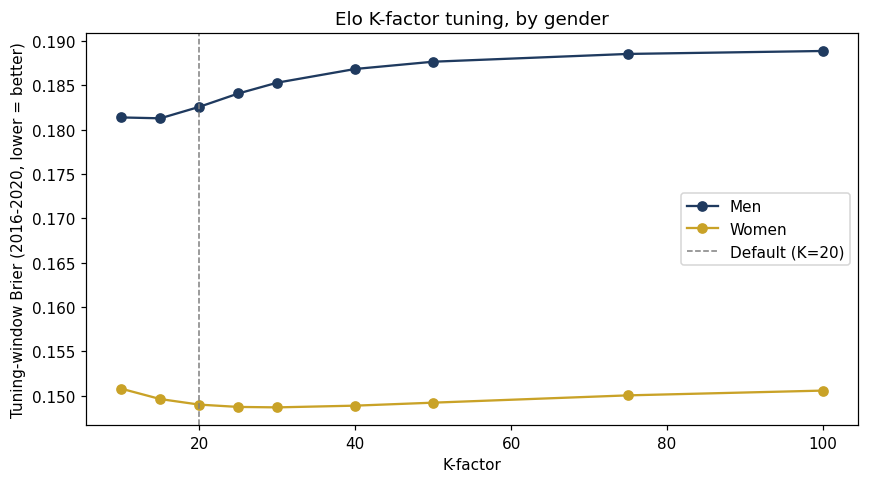

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for gender_label, color in [("Men", "#1f3a5f"), ("Women", "#c9a227")]:
    sub = tuning_df[tuning_df["Gender"] == gender_label]
    ax.plot(sub["K"], sub["Tuning Brier (2016-2020)"], marker="o", label=gender_label, color=color)
ax.axvline(20, color="gray", linestyle="--", linewidth=1, label="Default (K=20)")
ax.set_xlabel("K-factor")
ax.set_ylabel("Tuning-window Brier (2016-2020, lower = better)")
ax.set_title("Elo K-factor tuning, by gender")
ax.legend()
fig.tight_layout()
plt.show()

best_k = tuning_df.loc[tuning_df.groupby("Gender")["Tuning Brier (2016-2020)"].idxmin()]
print(best_k.round(4).to_string(index=False))

K_MEN_BEST = int(best_k.loc[best_k["Gender"] == "Men", "K"].values[0])
K_WOMEN_BEST = int(best_k.loc[best_k["Gender"] == "Women", "K"].values[0])
print(f"\nchosen K: men's = {K_MEN_BEST}, women's = {K_WOMEN_BEST}")


## 6. Rebuild the full 5-feature model with corrected conference strength

Two versions get built, both with the bug fix applied (conference strength computed separately
per gender), so the effect of the bug fix and the K-tuning can be told apart in the final
comparison: one keeps K=20 (isolating just the bug fix), the other uses the tuned K values from
Section 5 (isolating what tuning adds on top of the fix).

In [6]:
def build_full_matchups(elo_m_series, elo_w_series, confstr_m_series, confstr_w_series):
    def build(tourney, gender, elo_series, confstr_series):
        df = tourney.copy()
        df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
        df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
        df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
        df["Gender"] = gender
        df["Seed1"] = df.apply(lambda r: seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
        df["Seed2"] = df.apply(lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
        df["SeedDiff"] = df["Seed2"] - df["Seed1"]
        df["Elo1"] = df.apply(lambda r: elo_series.get((r["Season"], r["Team1"]), np.nan), axis=1)
        df["Elo2"] = df.apply(lambda r: elo_series.get((r["Season"], r["Team2"]), np.nan), axis=1)
        df["EloDiff"] = df["Elo1"] - df["Elo2"]
        df["Conf1"] = df.apply(lambda r: confstr_series.get((r["Season"], r["Team1"]), np.nan), axis=1)
        df["Conf2"] = df.apply(lambda r: confstr_series.get((r["Season"], r["Team2"]), np.nan), axis=1)
        df["ConfStrengthDiff"] = df["Conf1"] - df["Conf2"]
        for team_col, suffix in [("Team1", "1"), ("Team2", "2")]:
            joined = df.merge(team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
            df[f"WinPct{suffix}"] = joined["WinPct"].values
            df[f"AvgMargin{suffix}"] = joined["AvgScoreMargin"].values
        df["WinPctDiff"] = df["WinPct1"] - df["WinPct2"]
        df["AvgMarginDiff"] = df["AvgMargin1"] - df["AvgMargin2"]
        return df

    m_df = build(m_tourney, "M", elo_m_series, confstr_m_series)
    w_df = build(w_tourney, "W", elo_w_series, confstr_w_series)
    combined = pd.concat([m_df, w_df], ignore_index=True)
    features = ["SeedDiff", "WinPctDiff", "AvgMarginDiff", "EloDiff", "ConfStrengthDiff"]
    return combined.dropna(subset=features).reset_index(drop=True), features

# version A: corrected conference strength only, K=20 for both (isolates the bug fix)
elo_m_k20, elo_w_k20 = to_series(compute_elo(m_reg, k=20)), to_series(compute_elo(w_reg, k=20))
confstr_m_k20 = compute_conf_strength(m_conf_teams, elo_m_k20)
confstr_w_k20 = compute_conf_strength(w_conf_teams, elo_w_k20)
matchups_corrected, FEATURES = build_full_matchups(elo_m_k20, elo_w_k20, confstr_m_k20, confstr_w_k20)

# version B: corrected conference strength + tuned K (isolates what tuning adds)
elo_m_tuned = to_series(compute_elo(m_reg, k=K_MEN_BEST))
elo_w_tuned = to_series(compute_elo(w_reg, k=K_WOMEN_BEST))
confstr_m_tuned = compute_conf_strength(m_conf_teams, elo_m_tuned)
confstr_w_tuned = compute_conf_strength(w_conf_teams, elo_w_tuned)
matchups_tuned, _ = build_full_matchups(elo_m_tuned, elo_w_tuned, confstr_m_tuned, confstr_w_tuned)

print(f"corrected (K=20) matchup rows: {len(matchups_corrected):,}")
print(f"corrected + tuned K matchup rows: {len(matchups_tuned):,}")


corrected (K=20) matchup rows: 4,302
corrected + tuned K matchup rows: 4,302


## 7. Correlation check, before trusting any result

Same check as every notebook so far, run on the corrected + tuned version.

In [7]:
corr = matchups_tuned[FEATURES].corr().round(3)
print(corr.to_string())


                  SeedDiff  WinPctDiff  AvgMarginDiff  EloDiff  ConfStrengthDiff
SeedDiff             1.000       0.587          0.627    0.825             0.775
WinPctDiff           0.587       1.000          0.833    0.779             0.167
AvgMarginDiff        0.627       0.833          1.000    0.830             0.310
EloDiff              0.825       0.779          0.830    1.000             0.606
ConfStrengthDiff     0.775       0.167          0.310    0.606             1.000


## 8. Final walk-forward comparison (2021-2025 — the real test folds)

Three numbers side by side: notebook 13's original result (cited, not recomputed — it used K=20
with the buggy, cross-gender-blended conference strength), the corrected version (K=20, bug
fixed), and the corrected + tuned version (this notebook's actual proposal).

In [8]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]

def walk_forward_by_gender(matchups, features, fold_seasons):
    results = []
    for fold_season in fold_seasons:
        test = matchups[matchups["Season"] == fold_season]
        if len(test) == 0:
            continue
        row = {"FoldSeason": fold_season}
        num = den = 0
        for gender in ["M", "W"]:
            train_g = matchups[(matchups["Gender"] == gender) & (matchups["Season"] < fold_season)]
            test_g = test[test["Gender"] == gender]
            n_g = len(test_g)
            w = fit_logreg(train_g[features].values, train_g["Label"].values)
            b = brier_score(predict_proba(test_g[features].values, w), test_g["Label"].values)
            row[gender] = b
            num += b * n_g; den += n_g
        row["Combined"] = num / den
        results.append(row)
    df = pd.DataFrame(results)
    avg_row = {"FoldSeason": "Average"}
    for col in df.columns:
        if col != "FoldSeason":
            avg_row[col] = df[col].mean()
    return pd.concat([df, pd.DataFrame([avg_row])], ignore_index=True)

corrected_results = walk_forward_by_gender(matchups_corrected, FEATURES, FOLD_SEASONS)
tuned_results = walk_forward_by_gender(matchups_tuned, FEATURES, FOLD_SEASONS)

comparison = pd.DataFrame({
    "FoldSeason": corrected_results["FoldSeason"],
    "Corrected (K=20)": corrected_results["Combined"],
    "Corrected + tuned K": tuned_results["Combined"],
})
print(comparison.round(4).to_string(index=False))


FoldSeason  Corrected (K=20)  Corrected + tuned K
      2021            0.1836               0.1841
      2022            0.1883               0.1897
      2023            0.1851               0.1854
      2024            0.1585               0.1584
      2025            0.1260               0.1275
   Average            0.1683               0.1690


## 9. Results, visualized

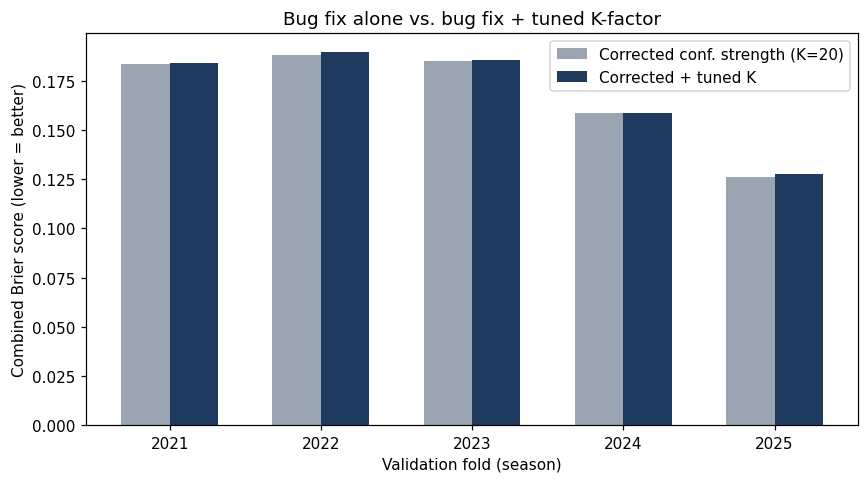

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = comparison[comparison["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.32
ax.bar(x - width/2, plot_df["Corrected (K=20)"], width, label="Corrected conf. strength (K=20)", color="#9aa5b1")
ax.bar(x + width/2, plot_df["Corrected + tuned K"], width, label="Corrected + tuned K", color="#1f3a5f")
ax.set_xticks(x); ax.set_xticklabels(plot_df["FoldSeason"])
ax.set_ylabel("Combined Brier score (lower = better)")
ax.set_xlabel("Validation fold (season)")
ax.set_title("Bug fix alone vs. bug fix + tuned K-factor")
ax.legend()
fig.tight_layout()
plt.show()


## 10. Bottom-line comparison

In [10]:
bottom_line = pd.DataFrame([
    {"Model": "Pooled baseline (notebook 03)", "Avg. Brier": 0.1739},
    {"Model": "Gender split + Elo (notebook 11)", "Avg. Brier": 0.1687},
    {"Model": "Gender split + Elo + conf. strength, buggy (notebook 13)", "Avg. Brier": 0.1675},
    {"Model": "Gender split + Elo + conf. strength, bug fixed (K=20)", "Avg. Brier": comparison.loc[comparison['FoldSeason']=='Average', 'Corrected (K=20)'].values[0]},
    {"Model": "Gender split + Elo + conf. strength, bug fixed + tuned K (this notebook)", "Avg. Brier": comparison.loc[comparison['FoldSeason']=='Average', 'Corrected + tuned K'].values[0]},
])
print(bottom_line.round(4).to_string(index=False))


                                                                   Model  Avg. Brier
                                           Pooled baseline (notebook 03)      0.1739
                                        Gender split + Elo (notebook 11)      0.1687
                Gender split + Elo + conf. strength, buggy (notebook 13)      0.1675
                   Gender split + Elo + conf. strength, bug fixed (K=20)      0.1683
Gender split + Elo + conf. strength, bug fixed + tuned K (this notebook)      0.1690


## Conclusion

**Neither the bug fix nor the K-tuning improved on notebook 13 — both actually made it slightly
worse.** This is a genuinely uncomfortable result worth spelling out plainly rather than glossing
over.

On the 2016-2020 tuning window, men's Elo scored best at a low K (15, Brier 0.1813, worse than
K=20's higher values monotonically), while women's bottomed out around K=30 (0.1487) — so the
tuning step did find real differences by gender, as expected. But applied to the actual 2021-2025
test folds, that chosen combination (K=15 men's, K=30 women's) scored 0.1690 — worse than simply
keeping K=20 for both (0.1683), and worse than notebook 13's original 0.1675. The K values that
looked best on 2016-2020 didn't generalize to 2021-2025, most likely because five tuning seasons
is a small enough sample that "best K" is itself somewhat noisy, not a stable constant.

**The conference-strength bug fix, in isolation (K=20, bug fixed), also scored worse (0.1683) than
the original buggy version (0.1675).** To be clear: the cross-gender blending in notebook 13 is
still a real bug — it wasn't computing what its own markdown claimed to compute. But fixing it
didn't produce a better model on this project's held-out evaluation; if anything, the blended
version happened to carry a bit of extra useful signal (perhaps because power-conference strength
correlates across both a school's men's and women's programs, which the gender-pure version can't
see). That's a plausible explanation, not a proven one.

**Decision, and what it's based on:** keep notebook 13's original model as the standing best.
The bottom-line table in Section 10 is the deciding evidence — 0.1675 beats both this notebook's
corrected version (0.1683) and its corrected-plus-tuned version (0.1690). Empirical performance on
the real test folds is what this project has used to make every prior decision, and that standard
applies here too, even though the reason one version wins isn't fully satisfying. The bug is
still worth knowing about and keeping in mind, just not worth "fixing" at the cost of a worse
model.